# Entrega 3 — Chunking de Manifestações Longas

Manifestações longas misturam vários fatos (o problema, o histórico, as consequências e os pedidos) e, indexadas como um único bloco,
perdem contexto: o vetor vira uma "média" de todos os assuntos. Além disso, os modelos de embedding têm um **limite de entrada** — o que
passa dele é simplesmente ignorado.

Neste notebook, as 5 manifestações mais longas são divididas com o `RecursiveCharacterTextSplitter` do LangChain em diferentes
configurações de `(chunk_size, chunk_overlap)`, e respondemos:

1. Como o overlap influencia a coesão semântica entre chunks consecutivos?
2. Qual configuração preserva melhor o sentido das denúncias?
3. No espaço 2D (PCA e t-SNE), os chunks de uma mesma manifestação ficam próximos?

## 1. Configuração

In [1]:
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from langchain_text_splitters import RecursiveCharacterTextSplitter
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from transformers.utils import logging as hf_logging
from huggingface_hub.utils import disable_progress_bars, logging as hub_logging

hf_logging.set_verbosity_error()
hf_logging.disable_progress_bar()
disable_progress_bars()
hub_logging.set_verbosity_error()
os.environ["TOKENIZERS_PARALLELISM"] = "false"

pd.set_option("display.max_colwidth", 160)
sns.set_theme(style="whitegrid")

# Mesmo modelo escolhido na Entrega 2
modelo = SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2")


def embed(textos):
    return modelo.encode(list(textos), normalize_embeddings=True)

In [2]:
with open("manifestacoes.json", encoding="utf-8") as f:
    df = pd.DataFrame(json.load(f))

df["n_caracteres"] = df["texto"].str.len()
df["n_tokens"] = [len(modelo.tokenizer(t)["input_ids"]) for t in df["texto"]]
longas = df.nlargest(5, "n_caracteres").sort_values("id").reset_index(drop=True)
print(f"Limite de entrada do modelo: {modelo.max_seq_length} tokens")
longas[["id", "categoria_oficial", "n_caracteres", "n_tokens"]]

Limite de entrada do modelo: 128 tokens


,id,categoria_oficial,n_caracteres,n_tokens
0,M006,infraestrutura,692,185
1,M015,saúde,705,161
2,M021,segurança,691,168
3,M027,educação,674,159
4,M036,meio ambiente,678,175


## 2. O problema: truncamento silencioso

As 5 manifestações longas passam do limite de 128 tokens do modelo. O `encode` não avisa: ele simplesmente corta o texto.
Abaixo, o trecho de cada uma que **nunca chega ao modelo** quando o texto é indexado inteiro:

In [3]:
def trecho_perdido(texto):
    ids = modelo.tokenizer(texto)["input_ids"]
    # descontamos os 2 tokens especiais (<s> e </s>) que o modelo adiciona
    return modelo.tokenizer.decode(ids[modelo.max_seq_length - 1:-1])


pd.DataFrame({"id": longas["id"], "trecho ignorado pelo modelo": longas["texto"].map(trecho_perdido)})

,id,trecho ignorado pelo modelo
0,M006,"o perto do número 120, e à noite não dá para ver porque o poste da esquina também está queimado. Pedimos a limpeza urgente das galerias pluviais, o conserto..."
1,M015,"que a demanda é grande, mas é preciso colocar mais médicos nos fins de semana, garantir pediatra de plantão e manter os remédios básicos no estoque."
2,M021,"rondas diárias da Polícia Militar e da Guarda Municipal nos horários de entrada e saída da escola, além da troca das lâmpadas e da instalação de câmeras de ..."
3,M027,"cito a ampliação das vagas, a contratação de mais auxiliares e a abertura da nova creche que foi prometida para o bairro há dois anos."
4,M036,"s na margem. Pedimos fiscalização da Secretaria de Meio Ambiente, a remoção do lixo, a instalação de placas e câmeras e a punição de quem estiver fazendo o ..."


Justamente o **final** das denúncias — onde o cidadão costuma colocar os pedidos concretos ("pedimos rondas…", "solicito a ampliação das
vagas…") — é descartado. O chunking resolve isso: cada pedaço cabe no limite e é indexado separadamente.

## 3. Configurações testadas

Todas usam o `RecursiveCharacterTextSplitter`, que tenta quebrar primeiro no separador mais "forte" da lista e só desce para o próximo se o pedaço
ainda estiver grande demais.

| Config. | chunk_size | chunk_overlap | separadores |
|---|---|---|---|
| **A** | 150 | 0 | padrão (`\n\n`, `\n`, espaço, caractere) |
| **B** | 150 | 50 | padrão |
| **C** | 300 | 60 | padrão |
| **D** | 300 | 60 | por frase (`. `, `, `, espaço, caractere) |
| **E** | 300 | 100 | por frase |

Como as manifestações não têm quebras de linha, com os separadores padrão o splitter acaba cortando **no espaço mais próximo do limite**,
ou seja, no meio das frases. As configurações D e E trocam os separadores por pontuação. Detalhe importante: com separadores de frase, o
overlap só é aplicado se couber uma **frase inteira** do fim do chunk anterior — em D (60 caracteres) quase nenhuma frase cabe, então na prática
não há sobreposição; em E (100 caracteres) a última frase curta de cada chunk é repetida no início do seguinte.

In [4]:
SEP_FRASE = [". ", ", ", " ", ""]
CONFIGS = {
    "A (150, 0)": RecursiveCharacterTextSplitter(chunk_size=150, chunk_overlap=0),
    "B (150, 50)": RecursiveCharacterTextSplitter(chunk_size=150, chunk_overlap=50),
    "C (300, 60)": RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=60),
    "D (300, 60, frases)": RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=60,
                                                          separators=SEP_FRASE, keep_separator="end"),
    "E (300, 100, frases)": RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=100,
                                                           separators=SEP_FRASE, keep_separator="end"),
}

registros = []
for cfg, splitter in CONFIGS.items():
    for _, row in longas.iterrows():
        for k, trecho in enumerate(splitter.split_text(row["texto"])):
            registros.append({"config": cfg, "id": row["id"], "categoria": row["categoria_oficial"],
                              "ordem": k, "chunk": trecho})
chunks = pd.DataFrame(registros)
chunks["embedding"] = list(embed(chunks["chunk"]))
chunks.groupby("config").agg(n_chunks=("chunk", "size"), tamanho_medio=("chunk", lambda s: s.str.len().mean())).round(0)

,n_chunks,tamanho_medio
config,,
"A (150, 0)",25,137.0
"B (150, 50)",35,138.0
"C (300, 60)",15,266.0
"D (300, 60, frases)",15,231.0
"E (300, 100, frases)",16,230.0


### 3.1 Exemplo: M021 (segurança perto da escola) em cada configuração

In [5]:
for cfg in CONFIGS:
    print(f"=== {cfg} ===")
    for trecho in chunks.query("config == @cfg and id == 'M021'")["chunk"]:
        print(f"  | {trecho}")
    print()

=== A (150, 0) ===
  | Moro há quinze anos no bairro Esperança e nunca vi a situação tão perigosa. A rua de trás da Escola Estadual Rui Barbosa virou ponto de venda de
  | drogas, e os alunos passam por ali todos os dias na saída das aulas. À noite, a iluminação é fraca e vários postes estão apagados, o que facilita os
  | assaltos. Na semana passada, uma professora teve a bolsa arrancada às 18h30, e um adolescente foi abordado por dois homens armados. Já fizemos
  | boletim de ocorrência, mas a viatura só aparece de vez em quando. Pedimos rondas diárias da Polícia Militar e da Guarda Municipal nos horários de
  | entrada e saída da escola, além da troca das lâmpadas e da instalação de câmeras de monitoramento na região.

=== B (150, 50) ===
  | Moro há quinze anos no bairro Esperança e nunca vi a situação tão perigosa. A rua de trás da Escola Estadual Rui Barbosa virou ponto de venda de
  | Estadual Rui Barbosa virou ponto de venda de drogas, e os alunos passam por ali todos os dias n

## 4. Métricas de coesão e fidelidade

Para cada configuração medimos:

* **coesão entre consecutivos**: cosseno médio entre o chunk *k* e o chunk *k+1* da mesma manifestação;
* **fidelidade**: cosseno médio entre cada chunk e o embedding da manifestação inteira (quanto do "assunto" o chunk carrega sozinho);
* **% cortados no meio da frase**: chunks que não terminam em `.`, `!` ou `?`;
* **% com palavra partida no início**: chunks que começam no meio de uma oração (primeira letra minúscula).

In [6]:
emb_doc = dict(zip(longas["id"], embed(longas["texto"])))

linhas = []
for cfg, g in chunks.groupby("config", sort=False):
    consecutivos = []
    for _, gi in g.groupby("id"):
        E = np.stack(gi.sort_values("ordem")["embedding"])
        consecutivos += [float(E[k] @ E[k + 1]) for k in range(len(E) - 1)]
    fidelidade = [float(e @ emb_doc[i]) for e, i in zip(g["embedding"], g["id"])]
    linhas.append({
        "config": cfg,
        "chunks": len(g),
        "coesão consecutivos": np.mean(consecutivos),
        "fidelidade ao documento": np.mean(fidelidade),
        "fidelidade mínima": np.min(fidelidade),
        "% cortados no meio da frase": 100 * (~g["chunk"].str.rstrip().str[-1].isin(list(".!?"))).mean(),
        "% começam no meio da oração": 100 * g["chunk"].str.strip().str[0].str.islower().mean(),
    })
metricas = pd.DataFrame(linhas).set_index("config").round(3)
metricas

,chunks,coesão consecutivos,fidelidade ao documento,fidelidade mínima,% cortados no meio da frase,% começam no meio da oração
config,,,,,,
"A (150, 0)",25,0.441,0.654,0.400,76.0,76.000
"B (150, 50)",35,0.580,0.651,0.395,80.0,62.857
"C (300, 60)",15,0.673,0.792,0.553,60.0,60.000
"D (300, 60, frases)",15,0.539,0.756,0.498,0.0,0.000
"E (300, 100, frases)",16,0.560,0.748,0.505,0.0,0.000


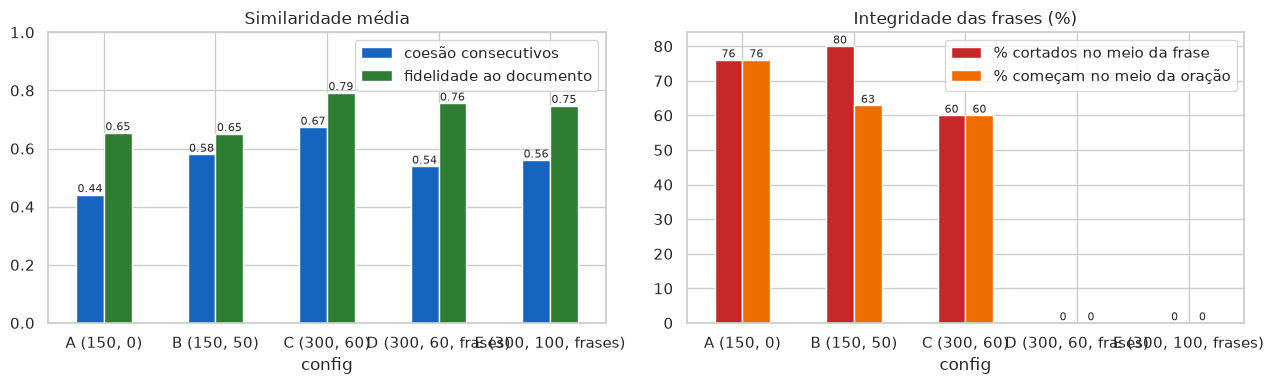

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
metricas[["coesão consecutivos", "fidelidade ao documento"]].plot(kind="bar", ax=axes[0], rot=0, color=["#1565c0", "#2e7d32"])
axes[0].set_ylim(0, 1)
axes[0].set_title("Similaridade média")
metricas[["% cortados no meio da frase", "% começam no meio da oração"]].plot(kind="bar", ax=axes[1], rot=0, color=["#c62828", "#ef6c00"])
axes[1].set_title("Integridade das frases (%)")
for ax in axes:
    for c in ax.containers:
        ax.bar_label(c, fmt="%.2f" if ax is axes[0] else "%.0f", fontsize=8)
plt.tight_layout()
plt.savefig("figuras/e3_metricas.png", dpi=150)
plt.show()

## 5. O chunking preserva o sentido? Teste de busca

O teste mais direto: para cada manifestação longa, fazemos uma consulta sobre um **detalhe específico** da denúncia (vários deles ficam no
trecho que o modelo ignora sem chunking) e verificamos em que posição a manifestação correta aparece entre as 40.

* **sem chunking**: cada manifestação vira um único vetor (truncado em 128 tokens);
* **com chunking**: as manifestações longas viram vários vetores e a nota da manifestação é a do seu **melhor chunk**; as curtas continuam com um vetor só.

In [8]:
CONSULTAS = {
    "M006": "a enchente estragou a geladeira e o sofá e pedimos obra de drenagem",
    "M015": "o antibiótico receitado estava em falta na farmácia da UPA",
    "M021": "instalar câmeras de monitoramento e trocar lâmpadas perto da escola",
    "M027": "abrir a nova creche que foi prometida para o bairro",
    "M036": "chorume do lixão contaminando o rio e peixes mortos",
}

emb_todos = embed(df["texto"])


def ranking_sem_chunking(q):
    s = emb_todos @ embed([q])[0]
    return list(df["id"].iloc[np.argsort(-s)])


def ranking_com_chunking(q, cfg):
    eq = embed([q])[0]
    nota = dict(zip(df["id"], emb_todos @ eq))  # manifestações curtas: vetor único
    for id_, g in chunks.query("config == @cfg").groupby("id"):
        nota[id_] = max(float(e @ eq) for e in g["embedding"])  # longas: melhor chunk
    return sorted(nota, key=nota.get, reverse=True)


resultados = []
for alvo, q in CONSULTAS.items():
    linha = {"alvo": alvo, "consulta": q, "sem chunking": ranking_sem_chunking(q).index(alvo) + 1}
    for cfg in CONFIGS:
        linha[cfg] = ranking_com_chunking(q, cfg).index(alvo) + 1
    resultados.append(linha)
posicoes = pd.DataFrame(resultados).set_index("alvo")
print("Posição da manifestação correta no ranking (1 = primeiro lugar):")
posicoes

Posição da manifestação correta no ranking (1 = primeiro lugar):


,consulta,sem chunking,"A (150, 0)","B (150, 50)","C (300, 60)","D (300, 60, frases)","E (300, 100, frases)"
alvo,,,,,,,
M006,a enchente estragou a geladeira e o sofá e pedimos obra de drenagem,1,1,1,1,1,1
M015,o antibiótico receitado estava em falta na farmácia da UPA,2,1,1,2,1,1
M021,instalar câmeras de monitoramento e trocar lâmpadas perto da escola,1,1,1,1,1,1
M027,abrir a nova creche que foi prometida para o bairro,5,1,1,1,1,1
M036,chorume do lixão contaminando o rio e peixes mortos,1,1,1,1,1,1


In [9]:
# Qual chunk respondeu cada consulta na melhor configuração?
for alvo, q in CONSULTAS.items():
    g = chunks.query("config == 'E (300, 100, frases)' and id == @alvo")
    eq = embed([q])[0]
    notas = [float(e @ eq) for e in g["embedding"]]
    k = int(np.argmax(notas))
    print(f"{alvo} | consulta: {q}\n      melhor chunk ({notas[k]:.2f}): {g['chunk'].iloc[k]}\n")

M006 | consulta: a enchente estragou a geladeira e o sofá e pedimos obra de drenagem
      melhor chunk (0.67): Os bueiros estão entupidos de terra e lixo há meses e nunca vieram fazer a limpeza. Na última chuva, a água entrou na minha casa e perdi a geladeira e o sofá. O vizinho, que é idoso, precisou ser retirado pelos bombeiros.

M015 | consulta: o antibiótico receitado estava em falta na farmácia da UPA
      melhor chunk (0.62): A sala de espera estava lotada, sem cadeiras suficientes, com gente sentada no chão e o bebedouro quebrado. Quando finalmente fomos atendidas, o médico receitou um antibiótico que estava em falta na farmácia da própria unidade, e tive que comprar em farmácia particular.

M021 | consulta: instalar câmeras de monitoramento e trocar lâmpadas perto da escola
      melhor chunk (0.66): Já fizemos boletim de ocorrência, mas a viatura só aparece de vez em quando. Pedimos rondas diárias da Polícia Militar e da Guarda Municipal nos horários de entrada e saída da es

## 6. Visualização dos chunks no espaço 2D

Projetamos os chunks da configuração E (e, para comparação, da configuração A) com **PCA** e **t-SNE**. Cada cor é uma manifestação; o
"X" marca o embedding da manifestação inteira. Também calculamos o **coeficiente de silhueta** (de −1 a 1; quanto maior, mais os chunks de
uma mesma manifestação ficam agrupados e separados dos demais), medido nos embeddings originais (768 dimensões, distância de cosseno).

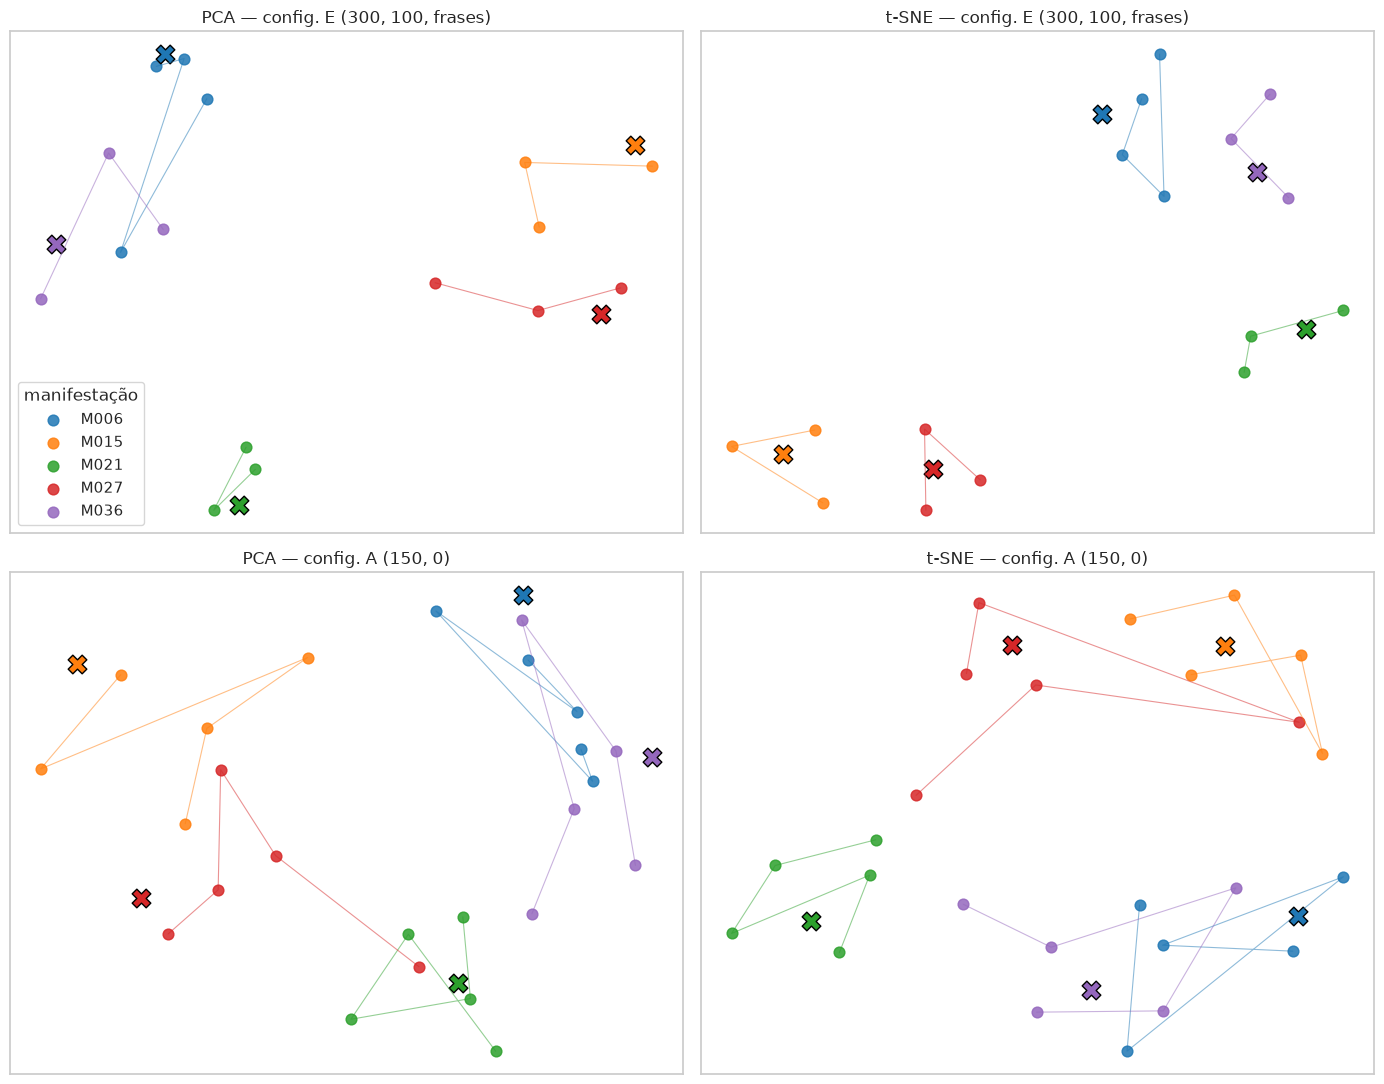

,silhueta por manifestação
"A (150, 0)",0.062
"B (150, 50)",0.117
"C (300, 60)",0.296
"D (300, 60, frases)",0.175
"E (300, 100, frases)",0.178


In [10]:
cores = dict(zip(longas["id"], sns.color_palette("tab10", 5)))


def projetar(cfg, ax_pca, ax_tsne):
    g = chunks.query("config == @cfg").reset_index(drop=True)
    E = np.vstack([np.stack(g["embedding"]), np.stack([emb_doc[i] for i in longas["id"]])])
    rotulos = list(g["id"]) + list(longas["id"])
    n = len(g)
    proj = {
        "PCA": PCA(n_components=2, random_state=42).fit_transform(E),
        "t-SNE": TSNE(n_components=2, perplexity=min(8, n // 3), random_state=42, init="pca",
                      metric="cosine").fit_transform(E),
    }
    for ax, (nome, P) in zip([ax_pca, ax_tsne], proj.items()):
        for id_ in longas["id"]:
            m = [k for k in range(n) if rotulos[k] == id_]
            ax.scatter(P[m, 0], P[m, 1], color=cores[id_], s=60, label=id_, alpha=0.85)
            ax.plot(P[m, 0], P[m, 1], color=cores[id_], lw=0.8, alpha=0.5)  # liga chunks consecutivos
            d = n + list(longas["id"]).index(id_)
            ax.scatter(P[d, 0], P[d, 1], color=cores[id_], marker="X", s=180, edgecolor="black")
        ax.set_title(f"{nome} — config. {cfg}")
        ax.set_xticks([])
        ax.set_yticks([])
    return silhouette_score(np.stack(g["embedding"]), g["id"], metric="cosine")


fig, axes = plt.subplots(2, 2, figsize=(14, 11))
silhuetas = {}
for linha_ax, cfg in zip(axes, ["E (300, 100, frases)", "A (150, 0)"]):
    silhuetas[cfg] = projetar(cfg, *linha_ax)
axes[0, 0].legend(title="manifestação", loc="best")
plt.tight_layout()
plt.savefig("figuras/e3_chunks_2d.png", dpi=130)
plt.show()

todas = {cfg: silhouette_score(np.stack(g["embedding"]), g["id"], metric="cosine")
         for cfg, g in chunks.groupby("config", sort=False)}
pd.Series(todas, name="silhueta por manifestação").round(3).to_frame()

In [11]:
# Similaridade média entre chunks da MESMA manifestação x de manifestações DIFERENTES (config. E)
g = chunks.query("config == 'E (300, 100, frases)'").reset_index(drop=True)
E = np.stack(g["embedding"])
S = E @ E.T
mesma = g["id"].to_numpy()[:, None] == g["id"].to_numpy()[None, :]
fora_diag = ~np.eye(len(g), dtype=bool)
print(f"Mesma manifestação:      {S[mesma & fora_diag].mean():.3f}")
print(f"Manifestações diferentes: {S[~mesma].mean():.3f}")

# Qual é o vizinho mais próximo de cada chunk?
vizinho = np.where(fora_diag, S, -1).argmax(axis=1)
g["vizinho mais próximo"] = g["id"].iloc[vizinho].to_numpy()
g["mesma manifestação?"] = np.where(g["id"] == g["vizinho mais próximo"], "sim", "não")
g[["id", "ordem", "chunk", "vizinho mais próximo", "mesma manifestação?"]]

Mesma manifestação:      0.542
Manifestações diferentes: 0.338


,id,ordem,chunk,vizinho mais próximo,mesma manifestação?
0,M006,0,"Venho registrar, pela terceira vez, o problema de alagamento na Rua do Comércio, no bairro Vila Nova. Sempre que chove mais forte, a água sobe mais de meio ...",M006,sim
1,M006,1,"Os bueiros estão entupidos de terra e lixo há meses e nunca vieram fazer a limpeza. Na última chuva, a água entrou na minha casa e perdi a geladeira e o sof...",M006,sim
2,M006,2,"O vizinho, que é idoso, precisou ser retirado pelos bombeiros. Além disso, a enxurrada abriu uma cratera no asfalto perto do número 120, e à noite não dá pa...",M006,sim
3,M006,3,"Pedimos a limpeza urgente das galerias pluviais, o conserto do asfalto e uma solução definitiva de drenagem para a rua.",M006,sim
4,M015,0,Quero registrar uma reclamação sobre o atendimento na UPA Zona Norte. No sábado levei minha filha de 4 anos com febre alta e fiquei mais de seis horas esper...,M015,sim
5,M015,1,"A sala de espera estava lotada, sem cadeiras suficientes, com gente sentada no chão e o bebedouro quebrado. Quando finalmente fomos atendidas, o médico rece...",M015,sim
6,M015,2,"Entendo que a demanda é grande, mas é preciso colocar mais médicos nos fins de semana, garantir pediatra de plantão e manter os remédios básicos no estoque.",M027,não
7,M021,0,"Moro há quinze anos no bairro Esperança e nunca vi a situação tão perigosa. A rua de trás da Escola Estadual Rui Barbosa virou ponto de venda de drogas, e o...",M021,sim
8,M021,1,"À noite, a iluminação é fraca e vários postes estão apagados, o que facilita os assaltos. Na semana passada, uma professora teve a bolsa arrancada às 18h30,...",M021,sim
9,M021,2,"Já fizemos boletim de ocorrência, mas a viatura só aparece de vez em quando. Pedimos rondas diárias da Polícia Militar e da Guarda Municipal nos horários de...",M021,sim


## 7. Discussão

### 7.1 Como o overlap influencia a coesão semântica entre chunks consecutivos?

* **Aumenta a coesão**: com os mesmos separadores e tamanho, passar de overlap 0 (A) para 50 (B) elevou a similaridade entre chunks consecutivos de **0,44 para 0,58**, e a silhueta por manifestação de 0,06 para 0,12. O overlap funciona como uma "costura": uma ideia cortada no fim de um chunk reaparece inteira no começo do seguinte. No exemplo de M021, a configuração A separa *"virou ponto de venda de"* | *"drogas"* e *"o que facilita os"* | *"assaltos"*: nenhum dos dois chunks sozinho diz qual é o problema. Na B, o segundo chunk recupera *"Estadual Rui Barbosa virou ponto de venda de drogas"* inteiro.
* **Mas parte dessa coesão é artificial**: consecutivos que compartilham 50–60 caracteres de texto idêntico *têm* de ser parecidos. Por isso C (300, 60) tem a maior coesão (0,67), embora 60% dos seus chunks ainda terminem no meio de uma frase. O overlap disfarça o corte sem eliminá-lo.
* **Tem custo**: B gera 35 chunks contra 25 de A (+40% de vetores para armazenar e comparar) e repete trechos, o que pode fazer o mesmo fato aparecer duas vezes em uma busca.
* **Com separadores de frase, o overlap só vale se couber uma frase inteira**: em D (overlap 60) nenhuma frase coube, e o resultado foi praticamente igual a não ter overlap. Em E (overlap 100) a última frase curta de cada chunk é repetida (*"Já fizemos boletim de ocorrência, mas a viatura só aparece de vez em quando."* abre o último chunk de M021), o que aumentou um pouco a coesão (0,54 → 0,56).

### 7.2 Qual configuração preserva melhor o sentido das denúncias?

**A configuração E — chunk_size 300, overlap 100, separadores por frase.** Justificativa:

1. **Nenhuma frase é cortada** (0% de cortes no meio, contra 60–80% nas configurações com separadores padrão). Cada chunk é legível sozinho, o que importa porque o chunk é o que o atendente vê como "trecho relevante" na busca.
2. **Cada chunk corresponde a uma parte da narrativa**: em M021 os chunks são *contexto* (tráfico perto da escola) → *fatos* (iluminação, assaltos, professora roubada) → *pedidos* (rondas, lâmpadas, câmeras). Em M006: *problema* (alagamento) → *prejuízos* (geladeira, sofá, cratera) → *pedido* (drenagem).
3. **Boa fidelidade ao documento** (0,75): cada chunk de 300 caracteres carrega contexto suficiente sobre o tema. Os chunks de 150 (A, B) têm fidelidade menor (~0,65), com mínimos de 0,40 — pedaços como *"boletim de ocorrência, mas a viatura só aparece de vez em quando. Pedimos rondas diárias da Polícia Militar e da Guarda Municipal nos horários de"* (configuração A, M021) perdem o assunto principal: rondas onde, e por quê?
4. **Resolve o truncamento**: todos os chunks cabem nos 128 tokens do modelo. No teste de busca, **sem chunking** a manifestação correta ficou em 2º lugar para a consulta sobre o antibiótico em falta (M015) e em **5º** para a creche prometida (M027), justamente porque esses trechos estão no final truncado. Com as configurações A, B, D e E, as 5 consultas encontram a manifestação correta em 1º lugar, e o chunk que "responde" é exatamente o trecho do pedido.

A configuração C (300, 60, separadores padrão) tem números agregados um pouco melhores (fidelidade 0,79, silhueta 0,30), mas 60% dos seus chunks começam ou terminam no meio de uma frase (*"…e tive que comprar em farmácia"* | *"farmácia da própria unidade…"*). No teste de busca, C deixou M015 em 2º lugar por uma margem mínima: seu melhor chunk teve 0,600, logo abaixo de M002 (*"Falta de remédio no posto…"*, 0,610), enquanto o de E teve 0,616. Essa diferença é pequena demais para, sozinha, decidir entre C e E; o que desempata é a legibilidade — métricas de similaridade média não capturam se o trecho mostrado ao atendente é uma frase completa.

### 7.3 Os chunks de uma mesma manifestação ficam próximos no espaço 2D?

**Sim, na maior parte.** Na configuração E, a similaridade média entre chunks da **mesma** manifestação é **0,54**, contra **0,34** entre manifestações diferentes, e **14 dos 16 chunks** têm como vizinho mais próximo outro chunk da mesma manifestação. No t-SNE, os cinco grupos aparecem separados, cada um em volta do "X" que marca o documento inteiro; no PCA, também formam grupos, com M006 (alagamento) e M036 (lixão) mais próximos entre si, porque ambos falam de chuva, água e lixo.

As duas exceções são informativas:

* O chunk final de **M015** (*"é preciso colocar mais médicos… garantir pediatra de plantão…"*) fica mais perto de **M027** (a creche) do que dos outros chunks da própria manifestação: ambos são **pedidos de contratação/ampliação de serviço público**. O chunking separa o *tipo de trecho* (reclamação × pedido) além do tema.
* O chunk do meio de **M036** (fumaça e chorume após a chuva) fica mais perto de **M006** (alagamento), pelo vocabulário comum de chuva e água escorrendo.

Na configuração A, os chunks ficam bem mais espalhados (silhueta 0,06): pedaços de 150 caracteres cortados no meio da frase carregam pouca informação e se parecem mais com trechos genéricos de outras manifestações.

*Observação:* o t-SNE com apenas ~16–25 pontos deve ser lido com cautela (as distâncias entre grupos não têm significado exato); por isso as conclusões se apoiam também na silhueta e nas similaridades calculadas no espaço original de 768 dimensões.

## 8. Conclusão

Chunking é necessário neste cenário por dois motivos concretos: o modelo **ignora** tudo que passa de 128 tokens (os pedidos no fim das denúncias) e um vetor único para um texto longo **dilui** os vários assuntos. Os parâmetros importam: chunks pequenos e sem overlap quebram o sentido; o overlap costura os cortes, mas infla a coesão e o número de vetores. Para textos narrativos sem quebra de linha, como estas manifestações, **trocar os separadores padrão por pontuação** foi a mudança de maior impacto, e um overlap grande o bastante para repetir uma frase inteira completa a solução. No sistema real, recomenda-se indexar as manifestações longas por chunks (configuração E) e ranquear cada manifestação pelo seu melhor chunk, mostrando esse trecho ao atendente como justificativa do resultado.
